# Mask Denoiser + LSTM Classifier for RF Data

This notebook implements a Noise2Self-based mask denoiser with stacked LSTM layers to predict residue, then classifies based on the cleaned signal.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


## 1. Load Data


In [2]:
# Load the data
data = torch.load('data_for_pytorch.pt', weights_only=False)
features = data['features']  # Shape: (41, 750)
labels = data['labels']      # Shape: (750,)

print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Number of classes: {len(torch.unique(labels))}")
print(f"Class distribution: {torch.bincount(labels)}")

# Transpose features to have shape (750, 41) - samples x features
features = features.T
print(f"\nTransposed features shape: {features.shape}")


Features shape: torch.Size([41, 750])
Labels shape: torch.Size([750])
Number of classes: 5
Class distribution: tensor([150, 150, 150, 150, 150])

Transposed features shape: torch.Size([750, 41])


## 2. Data Preprocessing and Train/Test Split


In [3]:
# Normalize features (zero mean, unit variance)
mean = features.mean(dim=0)
std = features.std(dim=0)
features_normalized = (features - mean) / (std + 1e-8)

# Add Gaussian noise to normalized features
noise_std = 0.25  # Standard deviation of Gaussian noise (adjust as needed)
gaussian_noise = torch.randn_like(features_normalized) * noise_std
features_normalized = features_normalized + gaussian_noise
print(f"Added Gaussian noise with std={noise_std} to normalized features")

# Train/Test split (80/20)
n_samples = features_normalized.shape[0]
n_train = int(0.8 * n_samples)
indices = torch.randperm(n_samples)
train_indices = indices[:n_train]
test_indices = indices[n_train:]

X_train = features_normalized[train_indices]
y_train = labels[train_indices]
X_test = features_normalized[test_indices]
y_test = labels[test_indices]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of classes: {len(torch.unique(labels))}")


Added Gaussian noise with std=0.25 to normalized features
Training set: 600 samples
Test set: 150 samples
Number of features: 41
Number of classes: 5


## 3. Define Model Architecture: Mask Denoiser + Stacked LSTM + Classifier


In [4]:
class MaskDenoiser1D(nn.Module):
    """
    Mask denoiser based on Noise2Self framework.
    Uses dilated 1D convolutions to denoise the input features.
    Treats feature vector as a 1D signal: (B, num_features) -> (B, 1, num_features)
    """
    def __init__(self, input_dim, channels=64, depth=4, kernel_size=3):
        super().__init__()
        layers = []
        in_ch = 1  # Input has 1 channel (the feature vector as a 1D signal)
        
        # Build dilated convolutional layers
        for i in range(depth):
            dil = 2 ** i
            pad = (kernel_size - 1) * dil // 2
            layers += [
                nn.Conv1d(in_ch, channels, kernel_size, padding=pad, dilation=dil),
                nn.BatchNorm1d(channels),
                nn.ReLU(inplace=True),
            ]
            in_ch = channels
        
        # Output layer
        layers += [nn.Conv1d(channels, 1, kernel_size=1)]
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        # x: (B, num_features) -> (B, 1, num_features) for Conv1d
        if x.dim() == 2:
            x = x.unsqueeze(1)  # (B, 1, num_features)
        # Process as 1D signal
        out = self.net(x)  # (B, 1, num_features)
        return out.squeeze(1)  # (B, num_features)


In [5]:
class ResiduePredictorLSTM(nn.Module):
    """
    Stacked LSTM layers to predict residue (difference between noisy and clean).
    """
    def __init__(self, input_dim, hidden_dim=128, num_layers=3, dropout=0.2):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        
        # Treat features as sequence: reshape (B, num_features) -> (B, num_features, 1)
        # Or use LSTM with input_dim as feature size
        # We'll use LSTM where each time step is one feature dimension
        self.lstm = nn.LSTM(
            input_size=1,  # Each feature is a scalar
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        
        # Output layer to predict residue
        self.fc = nn.Linear(hidden_dim, input_dim)
    
    def forward(self, x):
        # x: (B, num_features)
        # Reshape to (B, num_features, 1) for LSTM
        x = x.unsqueeze(2)  # (B, num_features, 1)
        
        # LSTM forward
        lstm_out, _ = self.lstm(x)  # (B, num_features, hidden_dim)
        
        # Use the last output or all outputs
        # We'll use all outputs and project to residue
        residue = self.fc(lstm_out)  # (B, num_features, num_features)
        # Take diagonal or use last output
        residue = residue[:, -1, :]  # (B, num_features) - use last hidden state
        
        return residue


In [6]:
class MaskDenoiserLSTMClassifier(nn.Module):
    """
    Complete model: Mask Denoiser -> Stacked LSTM (residue prediction) -> Classifier
    """
    def __init__(self, input_dim, num_classes, 
                 denoiser_channels=64, denoiser_depth=4,
                 lstm_hidden_dim=128, lstm_num_layers=3, lstm_dropout=0.2,
                 classifier_hidden_dims=[128, 64], classifier_dropout=0.3):
        super().__init__()
        
        # Mask denoiser
        self.denoiser = MaskDenoiser1D(input_dim, denoiser_channels, denoiser_depth)
        
        # LSTM residue predictor
        self.residue_predictor = ResiduePredictorLSTM(
            input_dim, lstm_hidden_dim, lstm_num_layers, lstm_dropout
        )
        
        # Classifier on cleaned signal
        classifier_layers = []
        prev_dim = input_dim
        for hidden_dim in classifier_hidden_dims:
            classifier_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(inplace=True),
                nn.Dropout(classifier_dropout)
            ])
            prev_dim = hidden_dim
        
        classifier_layers.append(nn.Linear(prev_dim, num_classes))
        self.classifier = nn.Sequential(*classifier_layers)
    
    def forward(self, x, return_intermediates=False):
        """
        x: (B, input_dim) - noisy input features
        
        Returns:
            logits: (B, num_classes) - classification logits
            (optional) intermediates: dict with denoised, residue, cleaned
        """
        # Step 1: Mask denoiser
        denoised = self.denoiser(x)  # (B, input_dim)
        
        # Step 2: LSTM predicts residue
        residue = self.residue_predictor(denoised)  # (B, input_dim)
        
        # Step 3: Cleaned signal = denoised - residue
        cleaned = denoised - residue  # (B, input_dim)
        
        # Step 4: Classify based on cleaned signal
        logits = self.classifier(cleaned)  # (B, num_classes)
        
        if return_intermediates:
            return logits, {
                'denoised': denoised,
                'residue': residue,
                'cleaned': cleaned
            }
        return logits


## 4. Noise2Self Loss Function


In [7]:
def noise2self_denoiser_loss(model, x, mask_ratio=0.15, replace_with="zero"):
    """
    Noise2Self loss for training the denoiser component.
    Masks random positions and predicts them from context.
    
    Args:
        model: MaskDenoiserLSTMClassifier model
        x: (B, input_dim) noisy input features
        mask_ratio: fraction of features to mask
        replace_with: "zero" or "noise"
    
    Returns:
        loss: MSE loss on masked positions
    """
    B, L = x.shape
    
    # Create random mask
    mask = (torch.rand(B, L, device=x.device) < mask_ratio)
    
    # Create masked input
    x_masked = x.clone()
    if replace_with == "zero":
        x_masked[mask] = 0.0
    elif replace_with == "noise":
        # Replace with random noise from batch statistics
        mu = x.mean(dim=1, keepdim=True)
        sigma = x.std(dim=1, keepdim=True).clamp_min(1e-6)
        noise = mu + sigma * torch.randn_like(x)
        x_masked[mask] = noise[mask]
    else:
        raise ValueError("replace_with must be 'zero' or 'noise'")
    
    # Get denoised output
    denoised = model.denoiser(x_masked)
    
    # Loss only on masked positions
    loss = F.mse_loss(denoised[mask], x[mask])
    
    return loss


## 5. Create Model and Data Loaders


In [8]:
# Model parameters
input_dim = X_train.shape[1]  # 41 features
num_classes = len(torch.unique(labels))  # 5 classes

# Create model
model = MaskDenoiserLSTMClassifier(
    input_dim=input_dim,
    num_classes=num_classes,
    denoiser_channels=64,
    denoiser_depth=4,
    lstm_hidden_dim=128,
    lstm_num_layers=3,
    lstm_dropout=0.2,
    classifier_hidden_dims=[128, 64],
    classifier_dropout=0.3
).to(device)

print(model)
print("\n" + "="*50)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Create data loaders
batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nBatch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")


MaskDenoiserLSTMClassifier(
  (denoiser): MaskDenoiser1D(
    (net): Sequential(
      (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (7): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU(inplace=True)
      (9): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): ReLU(inplace=True)
      (12): Conv1d(64, 1, kernel_size=(1,), stride=(1,))
    )
  )
  (residue_predictor): ResiduePredicto

## 6. Training Setup


In [9]:
# Loss functions
classification_criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)

# Training parameters
num_epochs = 150
denoiser_loss_weight = 0.3  # Weight for Noise2Self denoiser loss
classification_loss_weight = 1.0  # Weight for classification loss
residue_loss_weight = 0.2  # Weight for residue prediction loss (optional)


e:\Anaconda\envs\Ptorch\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 7. Training Loop


In [10]:
# Training history
train_losses = []
train_class_losses = []
train_denoiser_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

best_test_acc = 0.0
best_model_state = None

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_class_loss = 0.0
    train_denoiser_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        logits, intermediates = model(batch_features, return_intermediates=True)
        
        # Classification loss
        class_loss = classification_criterion(logits, batch_labels)
        
        # Noise2Self denoiser loss
        denoiser_loss = noise2self_denoiser_loss(model, batch_features, mask_ratio=0.15, replace_with="zero")
        
        # Optional: Residue loss (encourage residue to be meaningful)
        # We can add a loss that encourages the cleaned signal to be better than noisy
        # For now, we'll just use classification and denoiser losses
        
        # Combined loss
        total_loss = (classification_loss_weight * class_loss + 
                     denoiser_loss_weight * denoiser_loss)
        
        # Backward pass
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        
        # Statistics
        train_loss += total_loss.item()
        train_class_loss += class_loss.item()
        train_denoiser_loss += denoiser_loss.item()
        _, predicted = torch.max(logits.data, 1)
        train_total += batch_labels.size(0)
        train_correct += (predicted == batch_labels).sum().item()
    
    train_loss /= len(train_loader)
    train_class_loss /= len(train_loader)
    train_denoiser_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total
    train_losses.append(train_loss)
    train_class_losses.append(train_class_loss)
    train_denoiser_losses.append(train_denoiser_loss)
    train_accuracies.append(train_acc)
    
    # Validation phase
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)
            
            logits = model(batch_features)
            loss = classification_criterion(logits, batch_labels)
            
            test_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            test_total += batch_labels.size(0)
            test_correct += (predicted == batch_labels).sum().item()
    
    test_loss /= len(test_loader)
    test_acc = 100 * test_correct / test_total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    # Learning rate scheduling
    scheduler.step(test_loss)
    
    # Save best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state = model.state_dict().copy()
    
    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'  Train Total Loss: {train_loss:.4f}')
        print(f'    - Class Loss: {train_class_loss:.4f}, Denoiser Loss: {train_denoiser_loss:.4f}')
        print(f'  Train Acc: {train_acc:.2f}%')
        print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
        print()

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f'Best test accuracy: {best_test_acc:.2f}%')


Epoch [1/150]
  Train Total Loss: 1.1142
    - Class Loss: 0.9262, Denoiser Loss: 0.6267
  Train Acc: 78.17%
  Test Loss: 0.5763, Test Acc: 99.33%

Epoch [10/150]
  Train Total Loss: 0.0844
    - Class Loss: 0.0241, Denoiser Loss: 0.2009
  Train Acc: 99.67%
  Test Loss: 0.0184, Test Acc: 99.33%

Epoch [20/150]
  Train Total Loss: 0.0778
    - Class Loss: 0.0068, Denoiser Loss: 0.2365
  Train Acc: 100.00%
  Test Loss: 0.0207, Test Acc: 99.33%

Epoch [30/150]
  Train Total Loss: 0.0553
    - Class Loss: 0.0035, Denoiser Loss: 0.1729
  Train Acc: 100.00%
  Test Loss: 0.0041, Test Acc: 100.00%

Epoch [40/150]
  Train Total Loss: 0.0634
    - Class Loss: 0.0034, Denoiser Loss: 0.2002
  Train Acc: 100.00%
  Test Loss: 0.0320, Test Acc: 99.33%

Epoch [50/150]
  Train Total Loss: 0.0571
    - Class Loss: 0.0028, Denoiser Loss: 0.1810
  Train Acc: 100.00%
  Test Loss: 0.0419, Test Acc: 99.33%

Epoch [60/150]
  Train Total Loss: 0.0587
    - Class Loss: 0.0019, Denoiser Loss: 0.1893
  Train Acc:

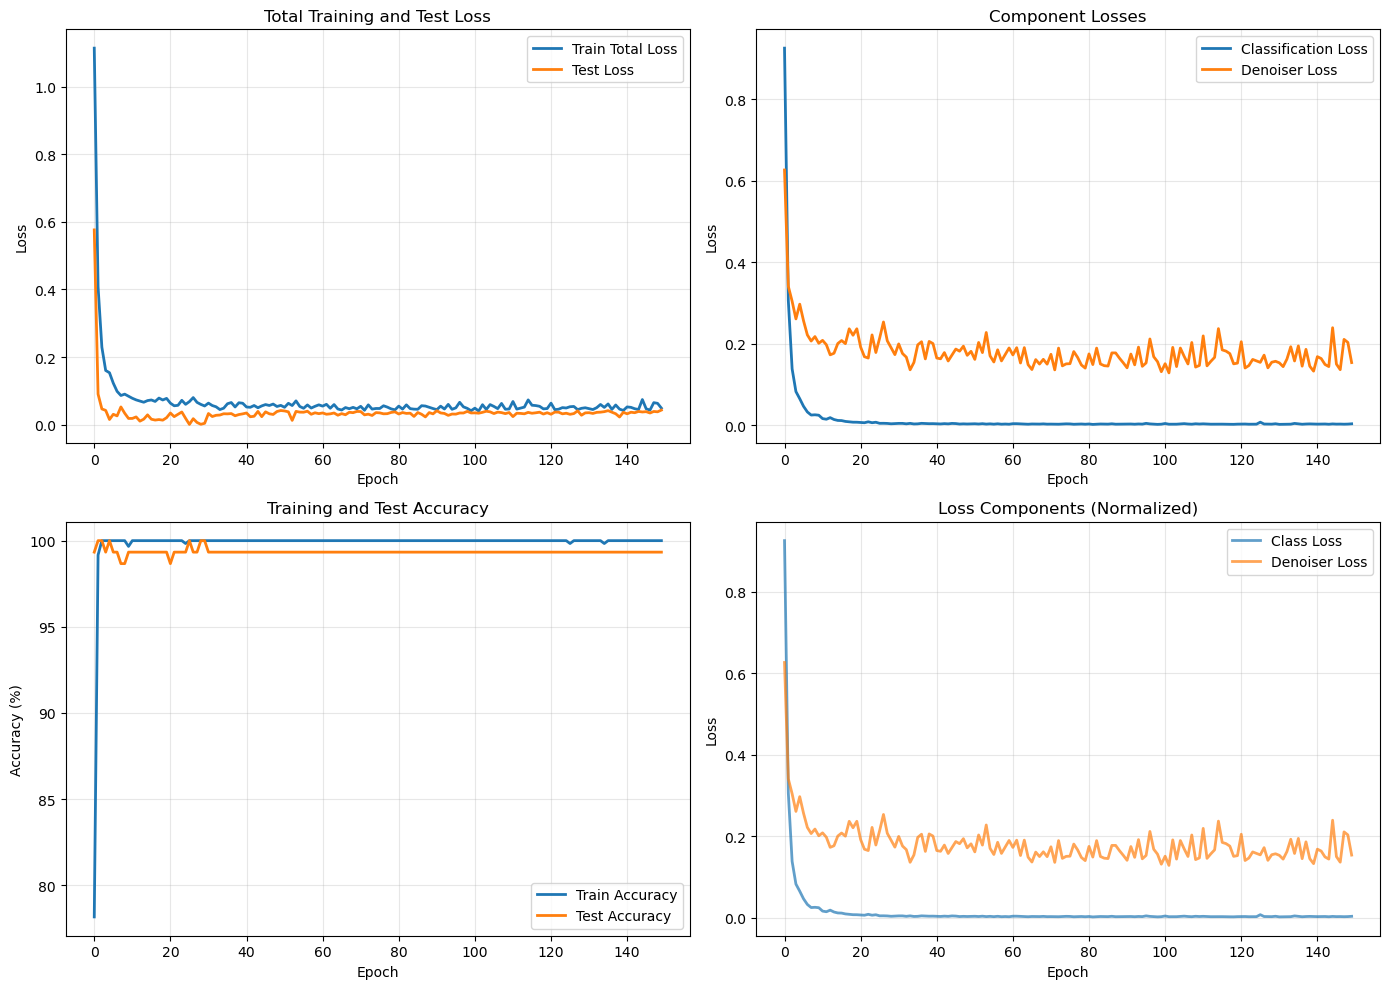

In [11]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total loss
axes[0, 0].plot(train_losses, label='Train Total Loss', linewidth=2)
axes[0, 0].plot(test_losses, label='Test Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Total Training and Test Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Component losses
axes[0, 1].plot(train_class_losses, label='Classification Loss', linewidth=2)
axes[0, 1].plot(train_denoiser_losses, label='Denoiser Loss', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Component Losses')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Accuracy curves
axes[1, 0].plot(train_accuracies, label='Train Accuracy', linewidth=2)
axes[1, 0].plot(test_accuracies, label='Test Accuracy', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].set_title('Training and Test Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Loss components comparison
axes[1, 1].plot(train_class_losses, label='Class Loss', linewidth=2, alpha=0.7)
axes[1, 1].plot(train_denoiser_losses, label='Denoiser Loss', linewidth=2, alpha=0.7)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Loss Components (Normalized)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Final Evaluation


In [12]:
# Evaluate on test set
model.eval()
all_preds = []
all_labels = []
all_cleaned = []

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        logits, intermediates = model(batch_features, return_intermediates=True)
        _, predicted = torch.max(logits, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_labels.numpy())
        all_cleaned.append(intermediates['cleaned'].cpu())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_cleaned = torch.cat(all_cleaned, dim=0).numpy()

# Calculate metrics
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))


Final Test Accuracy: 99.33%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       1.00      1.00      1.00        41
           2       1.00      0.97      0.99        34
           3       0.95      1.00      0.97        18
           4       1.00      1.00      1.00        32

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



## 10. Confusion Matrix


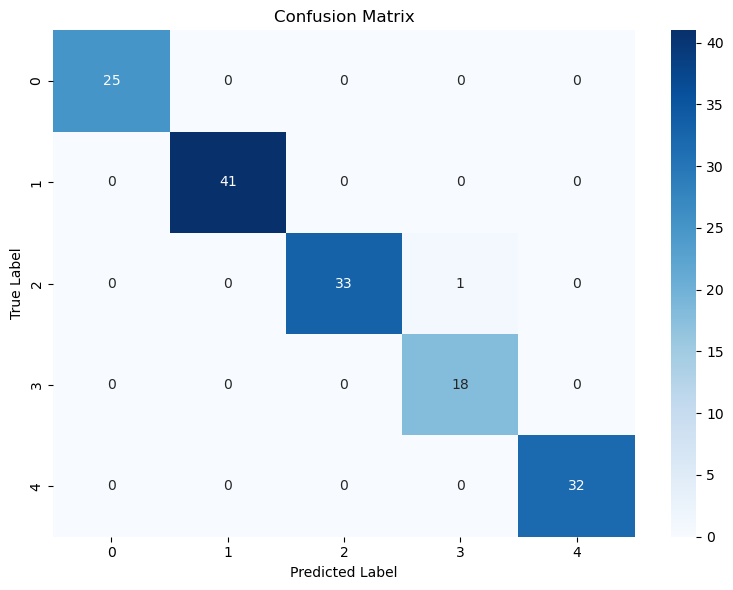

In [13]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


## 11. Visualize Denoising Effect (Optional)


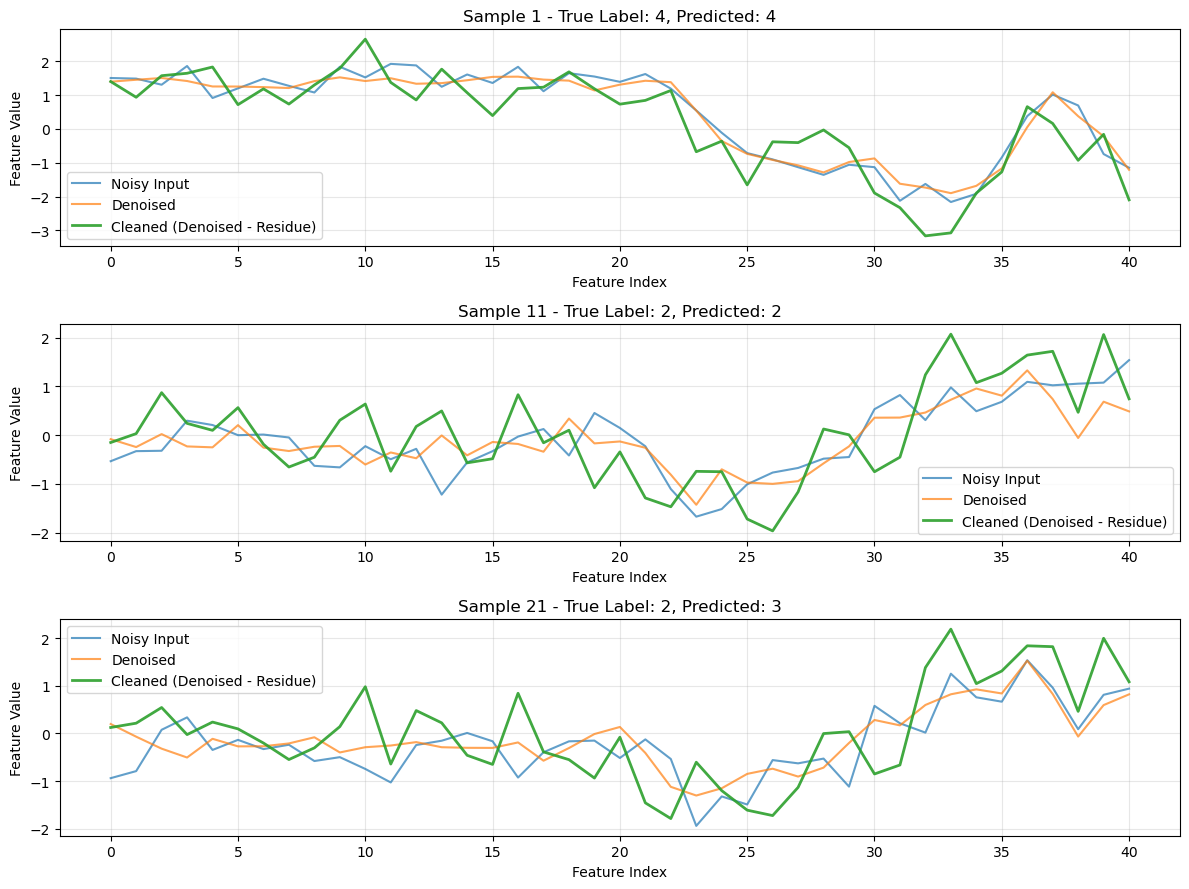

In [14]:
# Visualize denoising effect on a few samples
model.eval()
with torch.no_grad():
    # Get a few test samples
    sample_indices = [0, 10, 20]
    sample_features = X_test[sample_indices].to(device)
    logits, intermediates = model(sample_features, return_intermediates=True)
    
    noisy = sample_features.cpu().numpy()
    denoised = intermediates['denoised'].cpu().numpy()
    residue = intermediates['residue'].cpu().numpy()
    cleaned = intermediates['cleaned'].cpu().numpy()

# Plot
fig, axes = plt.subplots(len(sample_indices), 1, figsize=(12, 3*len(sample_indices)))
if len(sample_indices) == 1:
    axes = [axes]

for idx, (ax, i) in enumerate(zip(axes, sample_indices)):
    ax.plot(noisy[idx], label='Noisy Input', alpha=0.7, linewidth=1.5)
    ax.plot(denoised[idx], label='Denoised', alpha=0.7, linewidth=1.5)
    ax.plot(cleaned[idx], label='Cleaned (Denoised - Residue)', alpha=0.9, linewidth=2)
    ax.set_xlabel('Feature Index')
    ax.set_ylabel('Feature Value')
    ax.set_title(f'Sample {i+1} - True Label: {y_test[i].item()}, Predicted: {all_preds[np.where(np.array(sample_indices) == i)[0][0]]}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 12. Save Model (Optional)


In [15]:
# Save the trained model
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'input_dim': input_dim,
        'num_classes': num_classes,
        'denoiser_channels': 64,
        'denoiser_depth': 4,
        'lstm_hidden_dim': 128,
        'lstm_num_layers': 3,
        'lstm_dropout': 0.2,
        'classifier_hidden_dims': [128, 64],
        'classifier_dropout': 0.3
    },
    'normalization': {
        'mean': mean,
        'std': std
    },
    'test_accuracy': test_accuracy
}, 'mask_denoiser_lstm_model.pt')

print("Model saved as 'mask_denoiser_lstm_model.pt'")
print("\nTo load the model later:")
print("  checkpoint = torch.load('mask_denoiser_lstm_model.pt')")
print("  model = MaskDenoiserLSTMClassifier(**checkpoint['model_config'])")
print("  model.load_state_dict(checkpoint['model_state_dict'])")


Model saved as 'mask_denoiser_lstm_model.pt'

To load the model later:
  checkpoint = torch.load('mask_denoiser_lstm_model.pt')
  model = MaskDenoiserLSTMClassifier(**checkpoint['model_config'])
  model.load_state_dict(checkpoint['model_state_dict'])
